In [1]:
import numpy as np
import pandas as pd
import polars as pl
from polars import selectors as cs
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from pathlib import Path
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OrdinalEncoder, OneHotEncoder, TargetEncoder, Binarizer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.model_selection import train_test_split,cross_validate,KFold,GridSearchCV,RandomizedSearchCV
from sklearn.metrics import root_mean_squared_log_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.feature_selection import SelectFromModel
from sklearn.utils.validation import check_is_fitted
from typing import cast
from category_encoders import CountEncoder
from add_features import add_modified_features

%matplotlib inline

warnings.filterwarnings('ignore')

## Data Preprocessing

### Cast

In [2]:
def mycast(df):
    df['MSSubClass'] = df['MSSubClass'].apply(str)
    df['YrSold'] = df['YrSold'].astype(str)
    df['MoSold'] = df['MoSold'].astype(str)
    return df

### Clean

In [3]:
def clean(df):
    # maybe typo
    df["Exterior2nd"] = df["Exterior2nd"].replace({"Brk Cmn": "BrkComm"})
    df["GarageYrBlt"] = df["GarageYrBlt"].where(df.GarageYrBlt <= 2010, df.YearBuilt)
    return df

### Impute

In [4]:
def impute(df):
    # suitable
    df['Functional'] = df['Functional'].fillna('Typ') 
    df['Electrical'] = df['Electrical'].fillna("SBrkr") 
    df['KitchenQual'] = df['KitchenQual'].fillna("TA") 
    df["PoolQC"] = df["PoolQC"].fillna("None")
    # mode
    df['Exterior1st'] = df['Exterior1st'].fillna(df['Exterior1st'].mode()[0]) 
    df['Exterior2nd'] = df['Exterior2nd'].fillna(df['Exterior2nd'].mode()[0])
    df['SaleType'] = df['SaleType'].fillna(df['SaleType'].mode()[0])
    # zero
    for col in ('GarageYrBlt', 'GarageArea', 'GarageCars'):
        df[col] = df[col].fillna(0)
    # None
    for col in ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']:
        df[col] = df[col].fillna('None')
    for col in ('BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'):
        df[col] = df[col].fillna('None')
    
    # group mean
    # 同じ住宅タイプは同じ地域に集中する(都市計画的な意味で)だろうというアイデアに基づく
    df['MSZoning'] = df.groupby('MSSubClass')['MSZoning'].transform(lambda x: x.fillna(x.mode()[0]))
    
    # 残りの str 型は一律 None
    non_numeric_cols = df.select_dtypes(exclude='number').columns
    df[non_numeric_cols] = df[non_numeric_cols].fillna('None')

    # median
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

    # 残りの numerics 型は一律 0
    numeric_dtypes = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    numerics = []
    for i in df.columns:
        if df[i].dtype in numeric_dtypes:
            numerics.append(i)
    df.update(df[numerics].fillna(0))
    return df
        

### load

In [5]:
# 先に clean,impute,cast の定義セルを実行すること
def load_data(return_concat = False):
    # Read
    dir = Path("../../data/")
    train = pd.read_csv(dir / "train.csv", index_col='Id')
    test = pd.read_csv(dir / "test.csv", index_col='Id')
    # filter outlier
    outlier_ids = [524,1299]  # 確認した外れ値のId
    train = train.drop(outlier_ids)
    # Preprocessing
    df= pd.concat([train, test],)
    df = clean(df)
    df = impute(df)
    df = mycast(df)
    # Reform splits
    train = df.loc[train.index, :]
    test = df.loc[test.index, :]
    # Return concat or split
    if return_concat:
        return df
    else:
        return train, test
    
train, test = cast(tuple[pd.DataFrame,pd.DataFrame],load_data(return_concat=False))
test = test.drop(['SalePrice'],axis=1)
train.shape, test.shape

((1458, 80), (1459, 79))

### prepare

In [6]:
X = train.copy()
y = X.pop('SalePrice')
X_test = test.copy()

### build pipeline

In [7]:
from preprocess import build_target_transformer, build_preprocessor

log_standardize_y = build_target_transformer()
tree_preprocessor, reg_preprocessor = build_preprocessor()

### add features / train test split

In [8]:
# add modified
X = add_modified_features(pl.DataFrame(X))
X_test = add_modified_features(pl.DataFrame(X_test))

# split
X_train, X_va, y_train, y_va = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("-"*20 + "train valid shape" + "-"*20)
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_va: {X_va.shape}, y_va: {y_va.shape}")

print("-"*20 + "Has null values in X_train" + "-"*20)
s = X_train.isnull().sum()
print(s[s > 0])

--------------------train valid shape--------------------
X_train: (1166, 96), y_train: (1166,)
X_va: (292, 96), y_va: (292,)
--------------------Has null values in X_train--------------------
Series([], dtype: int64)


## Model Evaluate

### Ridge

Fold 1: train RMSLE = 0.1041 / valid RMSLE = 0.1298
Fold 2: train RMSLE = 0.1087 / valid RMSLE = 0.1096
Fold 3: train RMSLE = 0.1094 / valid RMSLE = 0.1043
Fold 4: train RMSLE = 0.1066 / valid RMSLE = 0.1182
Fold 5: train RMSLE = 0.1052 / valid RMSLE = 0.1250
CV平均: train 0.1068 / valid 0.1174
最終スコア(test RMSLE): 0.1182


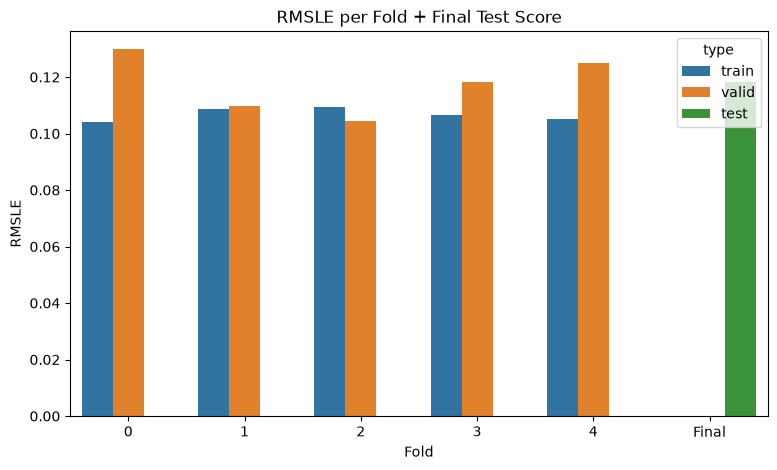

In [11]:
N_SELECT_FEATS = 30
alpha = 50.0
base_model = Pipeline([
    ("prep", reg_preprocessor),
    # ("select", SelectFromModel(Ridge(alpha=alpha), max_features=N_SELECT_FEATS, threshold=-np.inf)),
    ("ridge", Ridge(alpha=alpha))
])
model = TransformedTargetRegressor(
    regressor=base_model,
    transformer=log_standardize_y,
    check_inverse=False
)

folds = 5
cv = KFold(n_splits=folds, shuffle=True, random_state=42)
result = cross_validate(
    model, X_train, y_train,
    cv=cv,
    scoring="neg_root_mean_squared_log_error",
    return_train_score=True,
)

# スコア表示
train_scores = -result["train_score"]
valid_scores = -result["test_score"]

for i, (tr, va) in enumerate(zip(train_scores, valid_scores), 1):
    print(f"Fold {i}: train RMSLE = {tr:.4f} / valid RMSLE = {va:.4f}")
print(f"CV平均: train {train_scores.mean():.4f} / valid {valid_scores.mean():.4f}")

model.fit(X_train, y_train)
test_score = root_mean_squared_log_error(y_va, model.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score:.4f}")

# スコアグラフ
df = pl.DataFrame({
    "Fold": [str(i) for i in range(folds)] * 2 + ["Final"],
    "RMSLE": list(train_scores) + list(valid_scores) + [test_score],
    "type": ["train"] * folds + ["valid"] * folds + ["test"],
})

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Fold", y="RMSLE", hue="type")

plt.title("RMSLE per Fold + Final Test Score")
plt.show()


### grid search(Ridge)

In [ ]:
# alpha_candidates = [1, 2, 5, 10, 20, 50, 100]

# # selectステップ(特徴量選択用Ridge)とridgeステップ(最終回帰用Ridge)のalphaを連動させて探索
# param_grid = [
#     {
#         # "regressor__select__estimator__alpha": [alpha],
#         "regressor__ridge__alpha": [alpha],
#     }
#     for alpha in alpha_candidates
# ]

# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     scoring="neg_root_mean_squared_log_error",
#     cv=cv,
#     n_jobs=-1,
#     refit=True,
# )
# grid_search.fit(X_train, y_train)

# print(f"Best params: {grid_search.best_params_}")
# print(f"Best CV RMSLE: {-grid_search.best_score_:.4f}")

# best_model = grid_search.best_estimator_
# test_score_gs = root_mean_squared_log_error(y_va, best_model.predict(X_va))
# print(f"最終スコア(test RMSLE): {test_score_gs:.4f}")

# # alphaごとのCVスコア一覧
# cv_results = pd.DataFrame(grid_search.cv_results_)[
#     ["param_regressor__ridge__alpha", "mean_test_score", "std_test_score"]
# ].assign(
#     mean_test_RMSLE=lambda df: -df["mean_test_score"]
# ).sort_values("param_regressor__ridge__alpha")
# cv_results


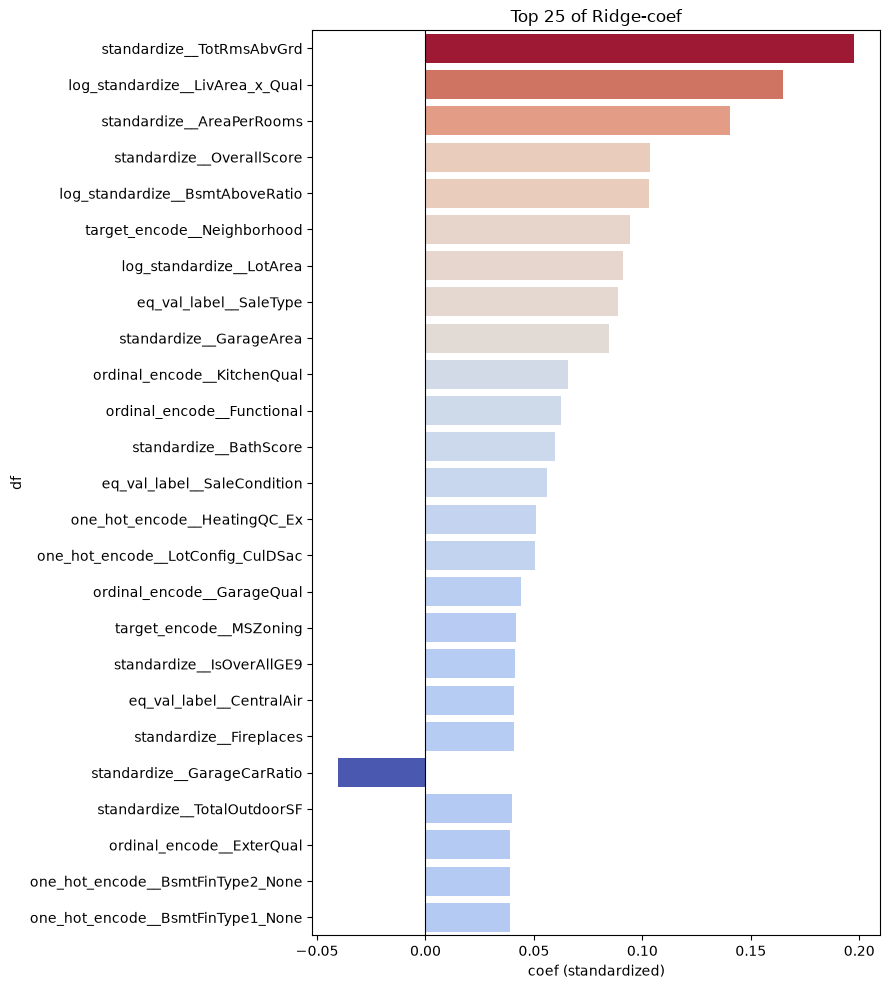

In [12]:
# 特徴量の寄与度（Ridge係数）トップ25
all_feature_names = model.regressor_.named_steps["prep"].get_feature_names_out()
# selected_mask = model.regressor_.named_steps["select"].get_support()
feature_names = all_feature_names  # [selected_mask]
coefs = model.regressor_.named_steps["ridge"].coef_

importance_df = pl.DataFrame({
    "feature": feature_names,
    "coef": coefs,
}).with_columns(
    pl.col("coef").abs().alias("abs_coef")
).sort("abs_coef", descending=True)

importance_df = importance_df.head(25)

plt.figure(figsize=(9, 10))
sns.barplot(
    data=importance_df.to_pandas(),
    x="coef", y="feature",
    hue="coef", palette="coolwarm", dodge=False, legend=False,
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 25 of Ridge-coef")
plt.xlabel("coef (standardized)")
plt.ylabel("df")
plt.tight_layout()

plt.show()


### XGBoost

In [ ]:
def make_xgb(**xgb_params):
    base_model_xgb = Pipeline([
        ("prep", tree_preprocessor),
        ("xgb", XGBRegressor(**xgb_params)),
    ])
    return TransformedTargetRegressor(
        regressor=base_model_xgb,
        transformer=log_standardize_y,
        check_inverse=False
    )

XGB_PARAMS = dict(
    n_estimators=1000,  # early stoppingが上限を決めるため大きめに設定
    learning_rate=0.01,
    max_depth=6,
    min_child_weight=1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric="rmse",
)

def fit_xgb_with_early_stopping(X_tr, y_tr, X_val, y_val, **xgb_params):
    """PipelineのprepとTransformedTargetRegressorの変換を手動で適用し、eval_setにearly stoppingを効かせる"""
    model = make_xgb(**xgb_params)
    prep = model.regressor.named_steps["prep"]
    xgb = model.regressor.named_steps["xgb"]

    y_tr_t = log_standardize_y.fit_transform(y_tr.to_numpy().reshape(-1, 1)).ravel()
    y_val_t = log_standardize_y.transform(y_val.to_numpy().reshape(-1, 1)).ravel()

    # prep内のTargetEncoderがyを要求するため、生のy_trを渡す
    X_tr_t = prep.fit_transform(X_tr, y_tr)
    X_val_t = prep.transform(X_val)

    xgb.fit(X_tr_t, y_tr_t, eval_set=[(X_val_t, y_val_t)], verbose=False)

    # 学習済みprep/xgbをそのままPipeline/TransformedTargetRegressorに差し込む
    model.regressor_ = model.regressor
    model.transformer_ = log_standardize_y
    model._training_dim = 1  # predict()内部で参照されるためfit()を通さない分手動設定
    return model

model_xgb = fit_xgb_with_early_stopping(
    X_train,
    y_train.to_numpy.reshape(-1, 1),
    X_va.to_numpy.reshape(-1, 1),
    y_va.to_numpy.reshape(-1, 1),
    **XGB_PARAMS)
best_iteration_xgb = model_xgb.regressor_.named_steps["xgb"].best_iteration
print(f"best_iteration: {best_iteration_xgb}")

test_score_xgb = root_mean_squared_log_error(y_va, model_xgb.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score_xgb:.4f}")


### grid search (XGBoost)

In [ ]:
param_dist_xgb = {
    "regressor__xgb__n_estimators": [500, 800],
    "regressor__xgb__learning_rate": [0.02, 0.03, 0.05],
    "regressor__xgb__max_leaves": [5, 7],
    "regressor__xgb__max_depth": [3, 4],
    "regressor__xgb__min_child_weight": [30, 50, 70, 100],
    "regressor__xgb__reg_alpha": [0.01, 0.05, 0.1],
    "regressor__xgb__reg_lambda": [1.0, 2.0, 5.0, 10.0],
    "regressor__xgb__subsample": [0.5, 0.6, 0.7],
    "regressor__xgb__colsample_bytree": [0.5, 0.6, 0.7],
}

# early_stopping_rounds付きだとeval_setが必須になりCVと相性が悪いため、探索用は早期終了なしのモデルを使う
search_model_xgb = make_xgb(**{k: v for k, v in XGB_PARAMS.items() if k not in ("early_stopping_rounds", "eval_metric")})

random_search_xgb = RandomizedSearchCV(
    estimator=search_model_xgb,
    param_distributions=param_dist_xgb,
    scoring="neg_root_mean_squared_log_error",
    cv=cv,
    n_iter=40,
    n_jobs=-1,
    refit=True,
    random_state=42,
)
random_search_xgb.fit(X_train, y_train)

print(f"Best params: {random_search_xgb.best_params_}")
print(f"Best CV RMSLE: {-random_search_xgb.best_score_:.4f}")

# 探索で見つかったベストパラメータでearly stoppingを使い最終学習し直す
best_xgb_params = {
    k.replace("regressor__xgb__", ""): v
    for k, v in random_search_xgb.best_params_.items()
}
best_model_xgb = fit_xgb_with_early_stopping(
    X_train, y_train, X_va, y_va,
    **{**XGB_PARAMS, **best_xgb_params},
)
print(f"best_iteration: {best_model_xgb.regressor_.named_steps['xgb'].best_iteration}")

test_score_gs_xgb = root_mean_squared_log_error(y_va, best_model_xgb.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score_gs_xgb:.4f}")

# パラメータごとのCVスコア一覧
cv_results_xgb = pd.DataFrame(random_search_xgb.cv_results_)[
    [
        "param_regressor__xgb__n_estimators",
        "param_regressor__xgb__learning_rate",
        "param_regressor__xgb__max_leaves",
        "param_regressor__xgb__max_depth",
        "param_regressor__xgb__min_child_weight",
        "param_regressor__xgb__reg_alpha",
        "param_regressor__xgb__reg_lambda",
        "mean_test_score",
        "std_test_score"
    ]
].assign(
    mean_test_RMSLE=lambda df: -df["mean_test_score"]

).sort_values("mean_test_RMSLE")
cv_results_xgb.sort_values('mean_test_RMSLE',ascending=True).head(15)

In [ ]:
# 特徴量の寄与度（XGBoost feature_importances_）トップ25
all_feature_names_xgb = best_model_xgb.regressor_.named_steps["prep"].get_feature_names_out()
# selected_mask_xgb = best_model_xgb.regressor_.named_steps["select"].get_support()
feature_names_xgb = all_feature_names_xgb  # [selected_mask_xgb]
importances_xgb = best_model_xgb.regressor_.named_steps["xgb"].feature_importances_

importance_df_xgb = pl.DataFrame({
    "feature": feature_names_xgb,
    "importance": importances_xgb,
}).sort("importance", descending=True)

importance_df_xgb = importance_df_xgb.head(25)

plt.figure(figsize=(9, 10))
sns.barplot(
    data=importance_df_xgb.to_pandas(),
    x="importance", y="feature",
    hue="importance", palette="coolwarm", dodge=False, legend=False,
)
plt.title("Top 25 of XGBoost feature_importances_")
plt.xlabel("importance")
plt.ylabel("df")
plt.tight_layout()

plt.show()


### SVR (kernel=rbf)

In [ ]:
base_model_svr = Pipeline([
    ("prep", preprocessor),
    ("svr", SVR(
        kernel="rbf",
        C=10,
        epsilon=0.05,
        gamma=0.001,
    ))
])
model_svr = TransformedTargetRegressor(
    regressor=base_model_svr,
    transformer=log_standardize_y,
    check_inverse=False
)

result_svr = cross_validate(
    model_svr, X_train, y_train,
    cv=cv,
    scoring="neg_root_mean_squared_log_error",
    return_train_score=True,
)

# スコア表示
train_scores_svr = -result_svr["train_score"]
valid_scores_svr = -result_svr["test_score"]

for i, (tr, va) in enumerate(zip(train_scores_svr, valid_scores_svr), 1):
    print(f"Fold {i}: train RMSLE = {tr:.4f} / valid RMSLE = {va:.4f}")
print(f"CV平均: train {train_scores_svr.mean():.4f} / valid {valid_scores_svr.mean():.4f}")

model_svr.fit(X_train, y_train)
test_score_svr = root_mean_squared_log_error(y_va, model_svr.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score_svr:.4f}")

### grid search (SVR)

In [ ]:
param_dist_svr = {
    "regressor__svr__C": [0.5, 1.0, 3.0, 5.0, 10.0],
    "regressor__svr__epsilon": [0.01, 0.02, 0.05],
    "regressor__svr__gamma": [0.0005, 0.001, 0.005, 0.01],
}

random_search_svr = RandomizedSearchCV(
    estimator=model_svr,
    param_distributions=param_dist_svr,
    scoring="neg_root_mean_squared_log_error",
    cv=cv,
    n_iter=100,
    n_jobs=-1,
    refit=True,
    random_state=42,
)
random_search_svr.fit(X_train, y_train)

print(f"Best params: {random_search_svr.best_params_}")
print(f"Best CV RMSLE: {-random_search_svr.best_score_:.4f}")

best_model_svr = random_search_svr.best_estimator_
test_score_gs_svr = root_mean_squared_log_error(y_va, best_model_svr.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score_gs_svr:.4f}")

# パラメータごとのCVスコア一覧
cv_results_svr = pd.DataFrame(random_search_svr.cv_results_)[
    [
        "param_regressor__svr__C",
        "param_regressor__svr__epsilon",
        "param_regressor__svr__gamma",
        "mean_test_score",
        "std_test_score"
    ]
].assign(
    mean_test_RMSLE=lambda df: -df["mean_test_score"]

).sort_values("mean_test_RMSLE")
cv_results_svr.sort_values('mean_test_RMSLE',ascending=True).head(15)

### stacking

In [ ]:
from sklearn.ensemble import StackingRegressor

# StackingRegressor/cross_validateは内部でクローンして再fitするため、
# early_stopping_rounds付きのbest_model_xgbはeval_setなしでエラーになる。
# best_iterationで木の本数を固定した早期終了なしのXGBoostを代わりに使う。
stacking_xgb_params = {
    k: v for k, v in {**XGB_PARAMS, **best_xgb_params}.items()
    if k not in ("early_stopping_rounds", "eval_metric")
}
stacking_xgb_params["n_estimators"] = best_model_xgb.regressor_.named_steps["xgb"].best_iteration + 1
stacking_xgb_estimator = make_xgb(**stacking_xgb_params)

stacking_model = StackingRegressor(
    estimators=[
        ("ridge", best_model),
        ("xgb", stacking_xgb_estimator),
        ("svr", best_model_svr),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=cv,
    n_jobs=-1,
    passthrough=False,
)

result_stack = cross_validate(
    stacking_model, X_train, y_train,
    cv=cv,
    scoring="neg_root_mean_squared_log_error",
    return_train_score=True,
)

# スコア表示
train_scores_stack = -result_stack["train_score"]
valid_scores_stack = -result_stack["test_score"]

for i, (tr, va) in enumerate(zip(train_scores_stack, valid_scores_stack), 1):
    print(f"Fold {i}: train RMSLE = {tr:.4f} / valid RMSLE = {va:.4f}")
print(f"CV平均: train {train_scores_stack.mean():.4f} / valid {valid_scores_stack.mean():.4f}")

stacking_model.fit(X_train, y_train)
test_score_stack = root_mean_squared_log_error(y_va, stacking_model.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score_stack:.4f}")

# スコアグラフ
df_stack = pl.DataFrame({
    "Fold": [str(i) for i in range(folds)] * 2 + ["Final"],
    "RMSLE": list(train_scores_stack) + list(valid_scores_stack) + [test_score_stack],
    "type": ["train"] * folds + ["valid"] * folds + ["test"],
})

plt.figure(figsize=(9, 5))
sns.barplot(data=df_stack, x="Fold", y="RMSLE", hue="type")

plt.title("Stacking: RMSLE per Fold + Final Test Score")
plt.show()

### submit

In [ ]:
from sklearn.base import clone

# ベストハイパーパラメータのRidge/XGBoost/SVRをベース推定器としたスタッキングモデルを
# 全学習データ(X, y)で最終学習
final_stacking_model = clone(stacking_model)
final_stacking_model.fit(X, y)

pred_final = final_stacking_model.predict(X_test)

submit_df = pd.DataFrame({
    "Id": test.index,
    "SalePrice": pred_final
}).to_csv("../../data/temp_ridge_submission(base_v2).csv",index=False)